# SIG742 - Modern Data Science - Mid Term

**Name:Siddharth Kulkarni**

**Student ID: 225167613**

**Email ID: siddharthskulkarni@gmail.com**

# Introduction

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

##Part 1 - Python Programming

**Answer 1.1**

In [3]:
def reverse_student_id(student_id):
    # Input validation to ensure the string starts with 's'
    if not isinstance(student_id, str):
        raise TypeError("Input must be a string")
    if not student_id or student_id[0].lower() != 's':
        raise ValueError("Input must be a non-empty string starting with 's'")

    reversed_list = []

    for char in student_id[::-1]:
      reversed_list.append(char)

    return reversed_list

In [4]:
reverse_student_id('s225167613')

['3', '1', '6', '7', '6', '1', '5', '2', '2', 's']

*   Using list comprehension to reverse the string into a list of characters
*   Optimization: List comprehension is concise and efficient for creating lists
*   Compared to appending in a loop, as it avoids multiple function calls

**Answer 1.2**

In [5]:
def reverse_student_id(student_id,start_index=0):
    # Input validation to ensure the string starts with 's'
    if not isinstance(student_id, str):
        raise TypeError("Input must be a string")
    if not student_id or student_id[0].lower() != 's':
        raise ValueError("Input must be a non-empty string starting with 's'")

    reversed_list = ""
    id_list = list(student_id)

    reversed_part = id_list[start_index:][::-1]
    result = id_list[:start_index] + reversed_part

    return ''.join(result)

In [6]:
reverse_student_id('s225167613',3)

's223167615'

**Answer 1.3**

In [7]:
def find_max_and_second_max(student_id, return_index=False):
    # Input validation
    if not isinstance(student_id, str):
        raise TypeError("Input student_id must be a string")
    if not student_id or student_id[0].lower() != 's':
        raise ValueError("Input student_id must be a non-empty string starting with 's'")
    if not all(char.isdigit() for char in student_id[1:]):
        raise ValueError("Student ID after 's' must contain only digits")

    digits = [int(char) for char in student_id[1:] if char.isdigit()]

    if not digits:
        raise ValueError("No digits found in student_id")

    max_num = digits[0]
    max_index = 0
    for i in range(len(digits)):
        if digits[i] > max_num:
            max_num = digits[i]
            max_index = i

    # Find second maximum number (considering distinct numbers)
    second_max = None
    for num in digits:
        if num != max_num and (second_max is None or num > second_max):
            second_max = num

    # If no second max exists (all numbers are same), return max_num
    second_max = max_num if second_max is None else second_max

    # Return results based on return_index flag
    if return_index:
        return max_num, max_index, second_max
    return max_num, second_max

In [8]:
max_num, max_index ,second_max = find_max_and_second_max('s225167613', True)
print(f"Max Number is {max_num} at location {max_index} and second max number is {second_max}")

Max Number is 7 at location 5 and second max number is 6


**Answer 1.4**

In [9]:
def find_digits(digits_str):
    # Input validation
    if not isinstance(digits_str, str):
        raise TypeError("Input digits_str must be a string")
    if not all(char.isdigit() for char in digits_str):
        raise ValueError("Input must contain only digits")

    digits = [int(char) for char in digits_str]

    if not digits:
        return []

    counts_naive = []
    for i in range(len(digits)):
        count = 0
        for j in range(i):
            if digits[j] < digits[i]:
                count += 1
        counts_naive.append(count)

    freq = [0] * 10  # Frequency array for digits 0-9
    counts_optimized = []
    for digit in digits:
        # Sum frequencies of digits smaller than current
        smaller_count = sum(freq[:digit])
        counts_optimized.append(smaller_count)
        # Update frequency
        freq[digit] += 1

    return counts_optimized

In [10]:
result = find_digits("225167613")
print(result)

[0, 0, 2, 0, 4, 5, 4, 0, 4]


**Answer 1.5**

In [11]:
def determine_3mt_winner(students):
    # Data wrangling: Extract values for normalization
    citations = [s["citations"] for s in students]
    comprehension = [s["comprehension"] for s in students]
    mistakes = [s["mistakes"] for s in students]

    # Input validation
    for s in students:
        if not all(isinstance(s[key], (int, float)) for key in ["citations", "comprehension", "mistakes"]):
            raise TypeError("All values must be numeric")
        if s["citations"] < 0 or s["comprehension"] < 0 or s["mistakes"] < 0:
            raise ValueError("Values must be non-negative")

    # Normalization to [0,1]
    min_cit = min(citations)
    max_cit = max(citations)
    min_comp = min(comprehension)
    max_comp = max(comprehension)
    min_mist = min(mistakes)
    max_mist = max(mistakes)

    if max_cit == min_cit or max_comp == min_comp or max_mist == min_mist:
        raise ValueError("Cannot normalize when min equals max for a criterion")

    # Calculate normalized scores and composite score
    for s in students:
        s["norm_citations"] = (s["citations"] - min_cit) / (max_cit - min_cit)
        s["norm_comprehension"] = (s["comprehension"] - min_comp) / (max_comp - min_comp)
        s["norm_mistakes"] = (max_mist - s["mistakes"]) / (max_mist - min_mist)
        s["composite_score"] = (s["norm_citations"] + s["norm_comprehension"] + s["norm_mistakes"]) / 3

    # Find winner
    winner = students[0]
    for s in students:
        if s["composite_score"] > winner["composite_score"]:
            winner = s
        elif s["composite_score"] == winner["composite_score"]:
            # Tiebreaker: Prefer lower typographical mistakes
            if s["mistakes"] < winner["mistakes"]:
                winner = s

    # Return winner and scores for transparency
    return {
        "winner": winner["name"],
        "composite_score": round(winner["composite_score"], 3),
        "details": [
            {
                "name": s["name"],
                "norm_citations": round(s["norm_citations"], 3),
                "norm_comprehension": round(s["norm_comprehension"], 3),
                "norm_mistakes": round(s["norm_mistakes"], 3),
                "composite_score": round(s["composite_score"], 3)
            } for s in students
        ]
    }

In [12]:
# Data as a list of dictionaries for easy manipulation
students = [
    {"name": "Kelvin", "citations": 520, "comprehension": 6, "mistakes": 0.11},
    {"name": "Lily", "citations": 27, "comprehension": 7, "mistakes": 0.05},
    {"name": "Thomas", "citations": 120, "comprehension": 3, "mistakes": 0.16},
    {"name": "Dina", "citations": 310, "comprehension": 5, "mistakes": 0.08},
    {"name": "Andrew", "citations": 55, "comprehension": 8, "mistakes": 0.01}
]

In [13]:
result = determine_3mt_winner(students)
print("\nDetails for all students:")
for detail in result["details"]:
    print(f"Name: {detail['name']}, Normalized Citations: {detail['norm_citations']}, "
          f"Normalized Comprehension: {detail['norm_comprehension']}, "
          f"Normalized Mistakes: {detail['norm_mistakes']}, "
          f"Composite Score: {detail['composite_score']}")


Details for all students:
Name: Kelvin, Normalized Citations: 1.0, Normalized Comprehension: 0.6, Normalized Mistakes: 0.333, Composite Score: 0.644
Name: Lily, Normalized Citations: 0.0, Normalized Comprehension: 0.8, Normalized Mistakes: 0.733, Composite Score: 0.511
Name: Thomas, Normalized Citations: 0.189, Normalized Comprehension: 0.0, Normalized Mistakes: 0.0, Composite Score: 0.063
Name: Dina, Normalized Citations: 0.574, Normalized Comprehension: 0.4, Normalized Mistakes: 0.533, Composite Score: 0.502
Name: Andrew, Normalized Citations: 0.057, Normalized Comprehension: 1.0, Normalized Mistakes: 1.0, Composite Score: 0.686


In [14]:
print(f"Winner: {result['winner']}")
print(f"Composite Score: {result['composite_score']}")

Winner: Andrew
Composite Score: 0.686


**Processing Steps**

*   Normalize all scores
*   Calculate the composite scores (Add all normalized scores and divide by 3)
*   Find the winner
    1.  Check the highest Composite scores
    2.  if there are multiple rows with same scores, choose one with minimun mistakes



**Final Outcome**
*   Andrew’s composite score (0.686) is highest, driven by top scores in comprehension (8, normalized to 1.0) and mistakes (0.01, normalized to 1.0), despite low citations (55, normalized to 0.057).
*   His presentation clarity (high comprehension, low errors) outweighs Kelvin’s high citations (520, normalized to 1.0) but weaker comprehension (6) and mistakes (0.11).

**Answer 1.6**

Function to find the optimal (minimal steps) way to generate exactly n coins using two magic machines.

**Understanding of the problem:**
*  Allan starts with 0 coins.
*  Machine 1: Consumes x coins, generates 2x + 1 coins (net gain: x + 1).
*  Machine 2: Consumes x coins, generates 2x + 2 coins (net gain: x + 2).
*  x must be between 0 and current coins inclusive.
*  The goal is to reach exactly n coins in the minimal number of machine uses.
*  This can be achieved by always using x = current coins (maximal), which corresponds to operations: new = 2 * current + k, where k=1 (Odd) for Machine 1, k=2 (Even) for Machine 2.
*  By working backwards from n to 0, we determine the sequence of machines: if current even, used Machine 2; if odd, Machine 1.
*  This method ensures minimal steps because it maximizes growth per step.
*  Time complexity: O(log n), since each backward step halves the value.


**To demonstrate For n=5:**

Backward: 1 odd -> Machine 1, current=(1-1)//2=0.
Forward: From 0, use Machine 1, x=0, generate=1, new=1.

For n=5:

5 odd ->1, current=(5-1)//2=2
2 even ->2, current=(2-2)//2=0
Reverse: [2,1]
Forward: Start 0, Machine 2 x=0 gen=2, new=2; then Machine 1 x=2 gen=5, new=2-2+5=5.

In [15]:
def generate_coins(n):
    if n < 1:
        raise ValueError("n must be at least 1")

    # Compute the sequence of machines backwards
    machines = []
    current = n
    while current > 0:
        if current % 2 == 1:
           # Odd → Used Machine 1
            machines.append(1)
            current = (current - 1) // 2
        else:
            # Even → Used Machine 2
            machines.append(2)
            current = (current - 2) // 2

    # Reverse to get forward sequence
    machines = machines[::-1]

    # Simulate forward to show steps and verify
    steps = []
    current_coins = 0
    for machine in machines:
        x = current_coins  # Always use maximal x = current_coins
        generated = 2 * x + machine
        new_coins = current_coins - x + generated  # Simplifies to current_coins + x + machine
        steps.append({
            "machine": machine,
            "x": x,
            "generated": generated,
            "new_total": new_coins
        })
        current_coins = new_coins

    return steps

In [16]:
for n in [1, 5, 7]:
  result = generate_coins(n)
  print(f"\nTo generate {n} coins (minimal steps: {len(result)}):")
  current = 0
  for step in result:
      print(f"From {current} coins, use Machine {step['machine']} with x={step['x']}, generate {step['generated']}, new total: {step['new_total']}")
      current = step['new_total']


To generate 1 coins (minimal steps: 1):
From 0 coins, use Machine 1 with x=0, generate 1, new total: 1

To generate 5 coins (minimal steps: 2):
From 0 coins, use Machine 2 with x=0, generate 2, new total: 2
From 2 coins, use Machine 1 with x=2, generate 5, new total: 5

To generate 7 coins (minimal steps: 3):
From 0 coins, use Machine 1 with x=0, generate 1, new total: 1
From 1 coins, use Machine 1 with x=1, generate 3, new total: 3
From 3 coins, use Machine 1 with x=3, generate 7, new total: 7


**Answer 1.7**

In [17]:
def split_sentences(text):
    """
    Splits text into sentences based on '.', '!', or '?' delimiters.
    Each sentence includes its ending punctuation.
    Returns a list of sentences.
    """
    if not isinstance(text, str):
        raise TypeError("Input must be a string")

    sentences = []
    current = ""
    for char in text:
        current += char
        if char in '.!?':
            # Strip leading/trailing spaces and add non-empty sentences
            stripped = current.strip()
            if stripped:
                sentences.append(stripped)
            current = ""

    # Handle any remaining text (if no final delimiter)
    if current.strip():
        sentences.append(current.strip())

    return sentences

In [18]:
def word_frequency(text):
    """
    Finds the most common word and returns top 30 words with their counts in a dictionary.
    Words are case-insensitive, punctuation is ignored, sorted by frequency (descending) and word (ascending).
    """
    # Step 1: Split into sentences
    sentences = split_sentences(text)

    #Step 2: Count words
    word_count = {}
    for sentence in sentences:
        # Convert to lowercase, replace punctuation with spaces
        cleaned = ""
        for char in sentence.lower():
            if char.isalpha() or char.isspace():
                cleaned += char
            else:
                cleaned += " "

        # Split into words and count
        words = cleaned.split()
        for word in words:
            if word:  # Ignore empty strings
                word_count[word] = word_count.get(word, 0) + 1

    # Find most common word
    most_common = ""
    max_count = 0
    for word, count in word_count.items():
        if count > max_count:
            most_common = word
            max_count = count
        elif count == max_count and word < most_common:
            most_common = word

    # Get top 30 words, sorted by count (descending) and word (ascending)
    sorted_words = sorted(word_count.items(), key=lambda x: x[1], reverse=True)
    top_30 = dict(sorted_words[:30])

    return sentences, most_common, top_30

In [19]:
text = "Hello world! This is a simple test. How are you doing today? I hope you are doing well. This test is only for checking the most common words in this document. Are you ready?"
sentences, most_common, top_words = word_frequency(text)

print("Sentences List:", sentences)
print("\nMost common word:", most_common)
print("\nTop 30 Most Common Words:\n", top_words)

Sentences List: ['Hello world!', 'This is a simple test.', 'How are you doing today?', 'I hope you are doing well.', 'This test is only for checking the most common words in this document.', 'Are you ready?']

Most common word: are

Top 30 Most Common Words:
 {'this': 3, 'are': 3, 'you': 3, 'is': 2, 'test': 2, 'doing': 2, 'hello': 1, 'world': 1, 'a': 1, 'simple': 1, 'how': 1, 'today': 1, 'i': 1, 'hope': 1, 'well': 1, 'only': 1, 'for': 1, 'checking': 1, 'the': 1, 'most': 1, 'common': 1, 'words': 1, 'in': 1, 'document': 1, 'ready': 1}


##Part 2 - Python Foundations for Data Science

In [20]:
def sum_digits(n ):
  r=0
  while n:r ,n = r + n % 10 , n // 10
  return r

In [21]:
def check_studentid( studentid ):
  x = sum_digits ( studentid )
  if x % 2 == 0:
    print('version I')
  else:
    print ('version II')

In [22]:
print ('Correct Version of Q2 for me is :')
check_studentid(225167613)

Correct Version of Q2 for me is :
version II


**Answer 2.1**

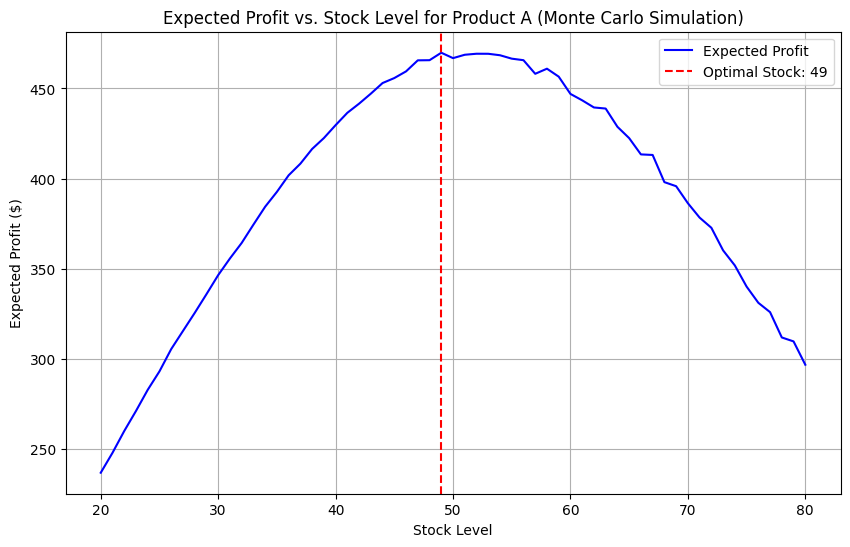

Optimal stock level: 49
Maximum expected profit: $469.83


In [25]:
# −−−−−−−−−−−−−−−−−−−−−−−−−−−−−−
# Product Information goes here,
#−−−−−−−−−−−−−−−−−−−−−−−−−−−−−−
selling_price = 20
cost_price = 8
holding_cost = 2
mean_demand = 50  # Define your own mean value of the daily demand.
std_demand = 15   # Define your own std value of the daily demand.
stock_range = np.arange(20, 81, 1)  # Add stock definition here.

n_simulations = 10000  # Number of Monte Carlo simulations. A large number like 10,000 ensures a reliable approximation of expected profits via the law of large numbers, balancing computational efficiency and accuracy.

# −−−−−−−−−−−−−−−−−−−−−−−−−−−−−−
# Monte Carlo Simulation −− run with n_simulations
# −−−−−−−−−−−−−−−−−−−−−−−−−−−−−−
expected_profits = [ ]
for stock in stock_range :
	profits = [ ]
	for _ in range ( n_simulations ):
		# Generate a random demand sample from the normal distribution, clipped to non-negative for realism
		demand = np.random.normal(mean_demand, std_demand)
		demand = max(0, demand)  # Clip to avoid negative demand, which is not possible in practice

		# Calculate sales as the minimum of stock and demand
		sales = min(stock, demand)

		# Calculate unsold inventory
		unsold = stock - sales

		# Calculate profit: revenue from sales minus total cost (stock cost + holding cost on unsold)
		profit = sales * selling_price - stock * cost_price - unsold * holding_cost
		profits.append(profit)

	# Compute the expected (average) profit for this stock level across all simulations
	expected_profit = np.mean(profits)
	expected_profits.append(expected_profit)

# Convert to numpy array for easier plotting
expected_profits = np.array(expected_profits)

# Find the optimal stock level (argmax of expected profits)
optimal_stock = stock_range[np.argmax(expected_profits)]
max_expected_profit = np.max(expected_profits)

# Plot the relationship between stock level and expected profit
plt.figure(figsize=(10, 6))
plt.plot(stock_range, expected_profits, label='Expected Profit', color='blue')
plt.axvline(x=optimal_stock, color='red', linestyle='--', label=f'Optimal Stock: {optimal_stock}')
plt.xlabel('Stock Level')
plt.ylabel('Expected Profit ($)')
plt.title('Expected Profit vs. Stock Level for Product A (Monte Carlo Simulation)')
plt.legend()
plt.grid(True)
plt.show()

# Print the optimal values
print(f"Optimal stock level: {optimal_stock}")
print(f"Maximum expected profit: ${max_expected_profit:.2f}")

**Answer 2.2**

Budget constraint not binding; joint optimum is sum of individual optima.


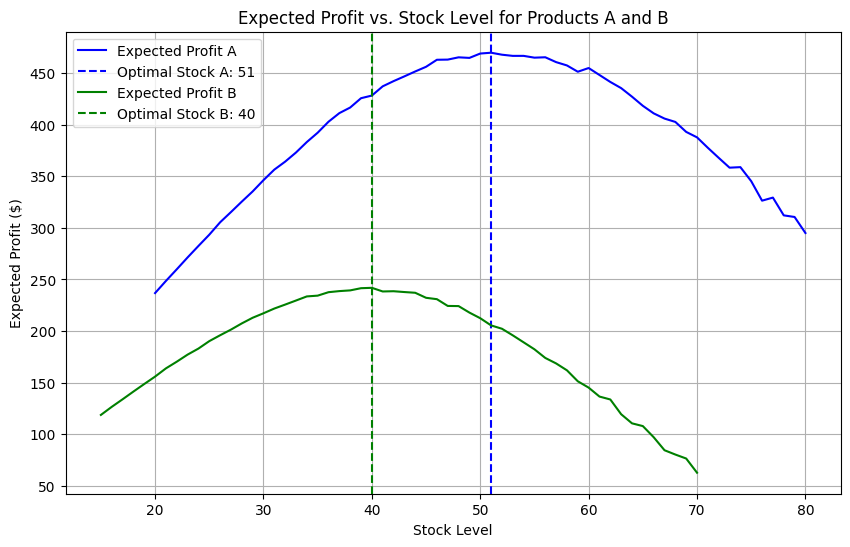

Optimal stock level for A: 51
Optimal stock level for B: 40
Maximum expected total profit: $711.78
Individual A profit: $469.86
Individual B profit: $241.93
Total stocking cost at optimum: $688.00
Budget utilization: 34.4%


In [24]:
# −−−−−−−−−−−−−−−−−−−−−−−−−−−−−−
# Product Information goes here,
#−−−−−−−−−−−−−−−−−−−−−−−−−−−−−−
# Product A
selling_price_A = 20
cost_price_A = 8
holding_cost_A = 2
mean_demand_A = 50  # Midpoint of stock range 20-80 for reasonable average daily demand
std_demand_A = 15   # Moderate variability, about 30% of mean
stock_range_A = np.arange(20, 81, 1)  # Integer levels from 20 to 80

# Product B
selling_price_B = 15
cost_price_B = 7
holding_cost_B = 1.5
mean_demand_B = 40  # Reasonable estimate, slightly lower than A, around midpoint of 15-70 (42.5)
std_demand_B = 12   # Slightly lower variability than A for product B
stock_range_B = np.arange(15, 71, 1)  # Integer levels from 15 to 70

n_simulations = 10000  # Number of Monte Carlo simulations for reliable estimates
budget = 2000  # Daily budget for total stocking costs (cost_A * stock_A + cost_B * stock_B <= budget)

# −−−−−−−−−−−−−−−−−−−−−−−−−−−−−−
# Monte Carlo Simulation for Product A (independent of B)
# −−−−−−−−−−−−−−−−−−−−−−−−−−−−−−
expected_profits_A = []
for stock in stock_range_A:
    profits = []
    for _ in range(n_simulations):
        demand = np.maximum(0, np.random.normal(mean_demand_A, std_demand_A))
        sales = min(stock, demand)
        unsold = stock - sales
        profit = sales * selling_price_A - stock * cost_price_A - unsold * holding_cost_A
        profits.append(profit)
    expected_profits_A.append(np.mean(profits))
expected_profits_A = np.array(expected_profits_A)

# Find optimal for A alone
optimal_stock_A_alone = stock_range_A[np.argmax(expected_profits_A)]
max_expected_profit_A = np.max(expected_profits_A)

# −−−−−−−−−−−−−−−−−−−−−−−−−−−−−−
# Monte Carlo Simulation for Product B (independent of A)
# −−−−−−−−−−−−−−−−−−−−−−−−−−−−−−
expected_profits_B = []
for stock in stock_range_B:
    profits = []
    for _ in range(n_simulations):
        demand = np.maximum(0, np.random.normal(mean_demand_B, std_demand_B))
        sales = min(stock, demand)
        unsold = stock - sales
        profit = sales * selling_price_B - stock * cost_price_B - unsold * holding_cost_B
        profits.append(profit)
    expected_profits_B.append(np.mean(profits))
expected_profits_B = np.array(expected_profits_B)

# Find optimal for B alone
optimal_stock_B_alone = stock_range_B[np.argmax(expected_profits_B)]
max_expected_profit_B = np.max(expected_profits_B)

# Since demands are independent and profits additive, joint expected profit = profit_A + profit_B
# Check if budget constraint binds at individual optima
total_stocking_cost_alone = cost_price_A * optimal_stock_A_alone + cost_price_B * optimal_stock_B_alone
if total_stocking_cost_alone <= budget:
    # Constraint not binding, joint optimal is individual optima
    optimal_stock_A = optimal_stock_A_alone
    optimal_stock_B = optimal_stock_B_alone
    max_expected_total_profit = max_expected_profit_A + max_expected_profit_B
    total_stocking_cost = total_stocking_cost_alone
    print("Budget constraint not binding; joint optimum is sum of individual optima.")
else:
    print("Budget constraint binds; perform 2D optimization.")

# Plot for both products on a single graph
plt.figure(figsize=(10, 6))
plt.plot(stock_range_A, expected_profits_A, label='Expected Profit A', color='blue')
plt.axvline(x=optimal_stock_A, color='blue', linestyle='--', label=f'Optimal Stock A: {optimal_stock_A}')
plt.plot(stock_range_B, expected_profits_B, label='Expected Profit B', color='green')
plt.axvline(x=optimal_stock_B, color='green', linestyle='--', label=f'Optimal Stock B: {optimal_stock_B}')
plt.xlabel('Stock Level')
plt.ylabel('Expected Profit ($)')
plt.title('Expected Profit vs. Stock Level for Products A and B')
plt.legend()
plt.grid(True)
plt.show()

# Print results
print(f"Optimal stock level for A: {optimal_stock_A}")
print(f"Optimal stock level for B: {optimal_stock_B}")
print(f"Maximum expected total profit: ${max_expected_total_profit:.2f}")
print(f"Individual A profit: ${max_expected_profit_A:.2f}")
print(f"Individual B profit: ${max_expected_profit_B:.2f}")
print(f"Total stocking cost at optimum: ${total_stocking_cost:.2f}")
print(f"Budget utilization: {total_stocking_cost / budget * 100:.1f}%")